In [89]:
import sys

sys.path.append("../src")
from training import (
    split_features_target,
    standardize_features,
    train_logistic_regression,
    train_random_forest
)
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


In [90]:


train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

In [91]:
X_train, X_test, y_train, y_test = split_features_target(
    train_df,
    test_df
)

Splitting features and target...
Features and target successfully separated.



In [92]:
X_train_scaled, X_test_scaled, scaler = standardize_features(
    X_train,
    X_test
)

Standardizing features...
Feature standardization completed.



In [93]:
logreg_model = train_logistic_regression(
    X_train_scaled,
    y_train
)

Training Logistic Regression model...
Logistic Regression training completed.



In [94]:
# Predict the income class for the test set
y_pred = logreg_model.predict(X_test_scaled)

In [95]:
# Compare the true labels with the predicted labels
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,1,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,0
9,0,0


In [96]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8546


In [97]:
# Display the classification metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4945
           1       0.74      0.61      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



In [98]:


# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[4609,  336],
       [ 611,  957]])

In [99]:


# Display the confusion matrix as a DataFrame
cm_df = pd.DataFrame(
    cm,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)

cm_df

,Predicted <=50K,Predicted >50K
Actual <=50K,4609,336
Actual >50K,611,957


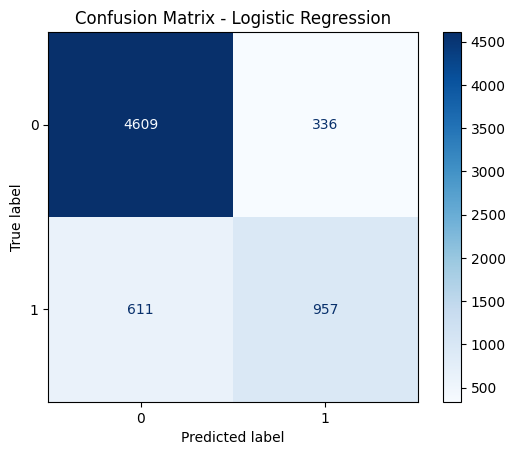

In [100]:

# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Train Random Forest

In [101]:
rf_model = train_random_forest(
    X_train,
    y_train
)

Training Random Forest model...
Random Forest training completed.



In [102]:
rf_y_pred = rf_model.predict(X_test)

In [103]:


accuracy_score(
    y_test,
    rf_y_pred
)

0.85014586212191

In [104]:

print(
    classification_report(
        y_test,
        rf_y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4945
           1       0.72      0.61      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.84      0.85      0.85      6513



In [105]:


confusion_matrix(
    y_test,
    rf_y_pred
)

array([[4578,  367],
       [ 609,  959]])